# L3 — Train

Latin → English, from scratch. No pretraining: at ~94k pairs the parallel data
teaches the task directly, which is what the paper did at larger scale.

**The number to beat is 0.31** — the copy baseline, i.e. emitting the Latin
unchanged. Unlike the Shakespeare task, where the baseline was 19.22 and
unbeatable, here almost any real translation clears it. That is the point of
the pivot: a score can finally mean what it appears to mean.

In [3]:
import os, subprocess, sys

REPO = "https://github.com/Amay-M-Nair/AttentionMech.git"

def has_src(d):
    return os.path.isdir(os.path.join(d, "src"))

# On Kaggle the notebook starts in /kaggle/working with no repo. Clone it, or
# pull if this session already cloned once.
if not any(has_src(d) for d in (os.getcwd(), os.path.dirname(os.getcwd()))):
    target = os.path.join(os.getcwd(), "AttentionMech")
    if os.path.isdir(os.path.join(target, ".git")):
        subprocess.run(["git", "-C", target, "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth", "1", REPO, target], check=True)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "sentencepiece", "sacrebleu"], check=True)

print("cwd:", os.getcwd())

Cloning into '/kaggle/working/AttentionMech'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.3 MB/s eta 0:00:00
cwd: /kaggle/working/AttentionMech


In [4]:
import os, sys, time

for candidate in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(candidate, "src")):
        ROOT = candidate
        sys.path.insert(0, ROOT)
        break

import matplotlib.pyplot as plt
import torch

from src.config import TransformerConfig, get_device
from src.dataset import TranslationDataset, load_split, make_dataloader
from src.evaluate import bleu, copy_baseline
from src.inference import translate_corpus
from src.spm_tokenizer import SPMTokenizer
from src.train import fit, load_checkpoint, overfit_batch
from src.transformer import build_model

%matplotlib inline
DATA = os.path.join(ROOT, "data")
CHECKPOINT = os.path.join(ROOT, "checkpoints", "latin.pt")

device = get_device()
torch.manual_seed(0)

tokenizer = SPMTokenizer(os.path.join(DATA, "spm8k.model"))
train_la, train_en = load_split(DATA, "train")
valid_la, valid_en = load_split(DATA, "valid")
test_la, test_en = load_split(DATA, "test")

valid_baseline = copy_baseline(valid_la, valid_en)
test_baseline = copy_baseline(test_la, test_en)

print("device:", device, "| vocab:", len(tokenizer))
print(f"train {len(train_la):,} | valid {len(valid_la):,} | test {len(test_la):,}")
print(f"copy baseline   valid {valid_baseline:.2f}   test {test_baseline:.2f}")

device: cuda | vocab: 8000
train 94,099 | valid 3,003 | test 3,003
copy baseline   valid 0.27   test 0.31


## Config

Every number here follows from something measured:

| Setting | Value | Why |
|---|---|---|
| vocab | 8,000 | L2 — small on purpose; a 32k vocab over 94k pairs is itself a cause of overfitting |
| `max_len` | 128 | L2 — covers 97.4% of pairs untruncated; 192 buys 2 points for 50% more compute |
| d_model / layers | 384, 4+4 | ~20M params. The 37M model memorised 18k Shakespeare pairs in 3 epochs |
| dropout | 0.3 | kept. Run 1 showed no overfitting across 40 epochs, so this was never the binding constraint and lowering it is untested |
| lr / warmup | 5e-4 / 4000 | **run 1 used 400.** Inverse-sqrt decay took the rate to 2.9e-5 by epoch 40 with BLEU still climbing; 4000 holds it ~3.2x higher throughout |
| epochs | 60 | run 1 was still improving at 40 - every epoch marked best, so patience 8 never fired |

In [5]:
MAX_LEN, BATCH = 128, 32

config = TransformerConfig(
    vocab_size=len(tokenizer),
    d_model=384, num_heads=8, num_layers=4, d_ff=1536,
    dropout=0.3, max_len=512,
)

model = build_model(config).to(device)
for name, count in model.count_parameters().items():
    print(f"  {name:<12} {count:>12,}")

  src_embed       3,072,000
  encoder         7,092,480
  decoder         9,454,848
  TOTAL          19,619,328


In [6]:
train_loader = make_dataloader(
    TranslationDataset(train_la, train_en, tokenizer, max_len=MAX_LEN), batch_size=BATCH)
valid_loader = make_dataloader(
    TranslationDataset(valid_la, valid_en, tokenizer, max_len=MAX_LEN),
    batch_size=BATCH, shuffle=False)

src, tgt_in, tgt_out = next(iter(train_loader))
print("src   ", tuple(src.shape), "|", tokenizer.decode(src[0])[:80])
print("target", tuple(tgt_out.shape), "|", tokenizer.decode(tgt_out[0])[:80])
print(f"\n{len(train_loader):,} batches per epoch")

src    (32, 29) | ut edatis et bibatis super mensam meam in regno et sedeatis super thronos iudica
target (32, 52) | That you may eat and drink at my table, in my kingdom: and may sit upon thrones,

2,941 batches per epoch


## Gate — overfit one batch

The check that has caught every wiring bug in this project. If the model cannot
memorise 32 pairs, something is wrong and a two-hour run would only discover it
slowly. Dropout off so nothing puts a floor under the loss.

In [7]:
probe_config = TransformerConfig(
    vocab_size=len(tokenizer), d_model=384, num_heads=8, num_layers=4,
    d_ff=1536, dropout=0.0, max_len=512)
probe = build_model(probe_config).to(device)

batch = tuple(t.to(device) for t in next(iter(train_loader)))
h = overfit_batch(probe, batch, steps=400, log_every=100)
print(f"\nloss {h['loss'][0]:.3f} -> {h['loss'][-1]:.4f}   acc {h['acc'][-1]:.1%}")
print("GATE:", "PASS" if h["acc"][-1] > 0.85 else "FAIL - do not start the long run")

del probe
torch.cuda.empty_cache()

step     1   loss 9.0181   acc  0.0%
step   100   loss 2.4917   acc 53.5%
step   200   loss 0.8270   acc 96.8%
step   300   loss 0.2724   acc 97.3%
step   400   loss 0.0615   acc 99.9%

loss 9.018 -> 0.0615   acc 99.9%
GATE: PASS


## Train

Validation scores with beam 4, so checkpoint selection optimises the metric
that gets reported. Early stopping on patience 8.

In [8]:
started = time.time()

history = fit(
    model, config, train_loader, valid_loader,
    valid_la, valid_en, tokenizer, device,
    epochs=60, patience=8, lr=5e-4, warmup=4000,
    label_smoothing=0.1, checkpoint_path=CHECKPOINT, baseline=valid_baseline,
    eval_beam=4, eval_alpha=1.0,
    eval_batch=24, eval_src_max_len=MAX_LEN, eval_max_len=200,
    eval_limit=1000, amp=True,
)

print(f"\ntrained in {(time.time() - started) / 60:.1f} min")

  epoch   1  step   200/2941  loss 8.467  acc  4.0%
  epoch   1  step   400/2941  loss 7.815  acc  4.6%
  epoch   1  step   600/2941  loss 7.434  acc  5.9%
  epoch   1  step   800/2941  loss 7.210  acc  7.3%
  epoch   1  step  1000/2941  loss 7.038  acc  8.5%
  epoch   1  step  1200/2941  loss 6.895  acc  9.4%
  epoch   1  step  1400/2941  loss 6.772  acc 10.2%
  epoch   1  step  1600/2941  loss 6.665  acc 10.9%
  epoch   1  step  1800/2941  loss 6.578  acc 11.4%
  epoch   1  step  2000/2941  loss 6.495  acc 12.0%
  epoch   1  step  2200/2941  loss 6.424  acc 12.5%
  epoch   1  step  2400/2941  loss 6.359  acc 13.0%
  epoch   1  step  2600/2941  loss 6.300  acc 13.4%
  epoch   1  step  2800/2941  loss 6.250  acc 13.8%
epoch   1  train 6.215/14.1%  valid 5.584/19.0%  BLEU[beam4/1000]   1.16 (baseline 0.27)  <- best
  epoch   2  step   200/2941  loss 5.463  acc 19.9%
  epoch   2  step   400/2941  loss 5.440  acc 20.1%
  epoch   2  step   600/2941  loss 5.421  acc 20.4%
  epoch   2  step 

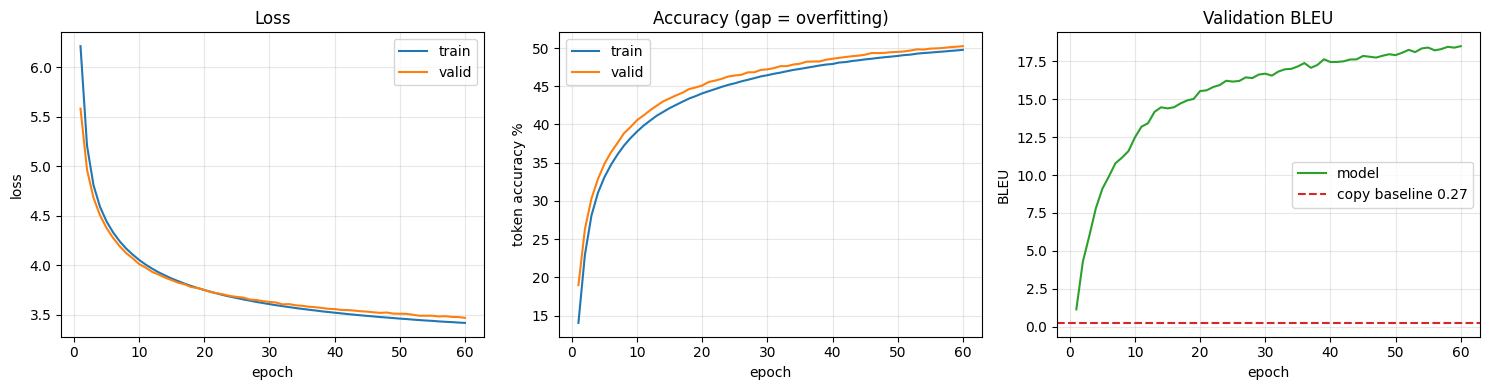

best validation BLEU 18.48   (baseline 0.27)
final train/valid accuracy gap -0.5 points


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["valid_loss"], label="valid")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title("Loss")

axes[1].plot(history["epoch"], [a*100 for a in history["train_acc"]], label="train")
axes[1].plot(history["epoch"], [a*100 for a in history["valid_acc"]], label="valid")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("token accuracy %")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title("Accuracy (gap = overfitting)")

axes[2].plot(history["epoch"], history["bleu"], color="tab:green", label="model")
axes[2].axhline(valid_baseline, color="tab:red", ls="--", label=f"copy baseline {valid_baseline:.2f}")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("BLEU")
axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_title("Validation BLEU")

plt.tight_layout(); plt.show()

best = max(history["bleu"])
gap = (history["train_acc"][-1] - history["valid_acc"][-1]) * 100
print(f"best validation BLEU {best:.2f}   (baseline {valid_baseline:.2f})")
print(f"final train/valid accuracy gap {gap:.1f} points")

## Sanity check

Read the output before trusting the number.

In [12]:
best_model, meta = load_checkpoint(CHECKPOINT, device=device)
print(f"loaded epoch {meta['epoch']}, valid BLEU {meta['score']:.2f}\n")

sample = valid_la[:8]
predictions = translate_corpus(best_model, sample, tokenizer, device,
                               batch_size=16, beam_size=4, length_penalty=1.0)

for i in range(8):
    print("LA  :", sample[i][:100])
    print("PRED:", predictions[i][:100])
    print("REF :", valid_en[i][:100])
    print()

loaded epoch 60, valid BLEU 18.48

LA  : Cn. Domitium non patris interitus, clarissimi viri, non avunculi mors, non spoliatio dignitatis ad r
PRED: The death of Gnaeus Domitius, not the death of his father, the most famous man, the death of his unc
REF : Was Gnaeus Domitius roused to recover freedom by my influence and not by the slaying of his illustri

LA  : dixitque ei petitionem unam parvulam ego deprecor a te ne confundas faciem meam dixit ei rex pete ma
PRED: And he said to him: I beseech thee one little one, I beseech thee not to confounded my face. And the
REF : And she said to him: I desire one small petition of thee; do not put me to confusion. And the king s

LA  : ut bene sit tibi et sis longevus super terram
PRED: That it may be well with thee, and thou mayst be far off upon the earth.
REF : That it may be well with thee, and thou mayest be long lived upon earth.

LA  : Dein turbatam incursione gentilium provinciam videns, et monasteriis quoque periculum imminere praev
PRE

## Done

`checkpoints/latin.pt` — the first model in this project measured against a
baseline it can actually beat.

Next: **L4** — tune decoding on validation, score test once, and report BLEU and
chrF beside the 0.31 baseline, split by sentence length and by source work.